# Compare two runs: Adaptive (HS) vs Adaptive (Covariance)

Provide **two paths** to `timeseries.csv` (one HS, one Covar).  
Optionally provide an **exact** `timeseries.csv` (or an exact column inside the CSV).


In [3]:
import numpy as np
import qutip as qt

def heisenberg_XYZ_open(N: int, Jx: float, Jy: float, Jz: float) -> qt.Qobj:
    """Open-boundary XYZ chain: H = sum_{i=0}^{N-2} (Jx X_i X_{i+1} + Jy Y_i Y_{i+1} + Jz Z_i Z_{i+1})."""
    sx, sy, sz = qt.sigmax(), qt.sigmay(), qt.sigmaz()
    si = qt.qeye(2)

    def op_on_sites(op_i, i, op_j, j):
        ops = [si] * N
        ops[i] = op_i
        ops[j] = op_j
        return qt.tensor(ops)

    H = 0
    for i in range(N - 1):  # open BCs
        H += Jx * op_on_sites(sx, i, sx, i + 1)
        H += Jy * op_on_sites(sy, i, sy, i + 1)
        H += Jz * op_on_sites(sz, i, sz, i + 1)
    return qt.Qobj(H)

def sigma0_z_polarized(N: int) -> qt.Qobj:
    """Product density matrix |0><0|^{⊗N} (max +Z polarization, no x/y, no entanglement)."""
    ket0 = qt.basis(2, 0)          # |0> : +1 eigenstate of sigmaz
    rho0 = ket0 * ket0.dag()       # |0><0|
    return qt.tensor([rho0] * N)

def Sz0(N: int, site: int = 0) -> qt.Qobj:
    """Single-site observable σ^z_site (default site 0)."""
    sz = qt.sigmaz()
    si = qt.qeye(2)
    ops = [si] * N
    ops[site] = sz
    return qt.tensor(ops)

# --- Example usage ---
N = 10
Jx, Jy, Jz = 1.0, -1, 1e-1   # inputs
H = heisenberg_XYZ_open(N, Jx, Jy, Jz)

rho0 = sigma0_z_polarized(N)
O = Sz0(N, site=0)

# time grid, ħ=1 (QuTiP uses ħ=1 units by default)
tlist = np.linspace(0.0, 1.0, 100)

# Schrödinger picture: <O>(t) = Tr[ O ρ(t) ]
res = qt.mesolve(H, rho0, tlist, c_ops=[], e_ops=[O])
exp_Sz0 = np.array(res.expect[0])/2

print("⟨Sz0⟩(t=0) =", exp_Sz0[0])


⟨Sz0⟩(t=0) = 0.5


In [15]:
# --- Inputs: set your two paths here ---
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

folder_path_ = "/home/tomas/phoenix/data/"
_file_path = "/timeseries.csv"
# Required
path_hs    = Path(
            folder_path_ +
    "20260205_153944__XY__N10__ell5__m2__eps1e-10__ptail2__dt4.000e-03__tmax0.4__seedZ0__sigma_HS"
            + _file_path
            ).expanduser()
path_covar = Path(
            folder_path_ +
            "20260205_162640__XY__N10__ell5__m2__eps1e-10__ptail2__dt4.000e-03__tmax0.4__seedZ0__sigmaultra-Z"
    + _file_path
            ).expanduser()

#"20260205_152652__XY__N10__ell5__m2__eps1e-10__ptail2__dt1.000e-02__tmax1__seedZ0__sigmaZ-global" 
#"20260205_152526__XY__N10__ell5__m2__eps1e-10__ptail2__dt1.000e-02__tmax1__seedZ0__sigma_HS" 
                        
# If you want to force a specific observable column name, set it here. Otherwise it's auto-detected.
observable_col_preference = None

# Plot
PLOT_DPI = 140


In [16]:
# --- Helpers ---
def detect_time_col(df: pd.DataFrame) -> str:
    for cand in ["t","time"]:
        if cand in df.columns:
            return cand
    # fallback: first numeric col
    nums = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not nums:
        raise ValueError("No numeric columns found (cannot detect time column).")
    return nums[0]

def detect_observable_col(df: pd.DataFrame, preferred: str | None = None) -> str:
    if preferred is not None and preferred in df.columns:
        return preferred

    # common names in your runs
    cands = [
        "O_{\ell, m, \epsilon}",
        "O_{\ell,m,\epsilon}",
        "O_lm_eps",
        "obs",
        "ev",
        "value",
    ]
    for c in cands:
        if c in df.columns and pd.api.types.is_numeric_dtype(df[c]):
            return c

    tcol = detect_time_col(df)
    nums = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != tcol]
    if not nums:
        raise ValueError("No numeric observable column found.")
    return nums[0]

def standardize(df: pd.DataFrame, label: str) -> pd.DataFrame:
    df = df.copy()
    tcol = detect_time_col(df)
    ocol = detect_observable_col(df, observable_col_preference)
    df = df.rename(columns={tcol:"t", ocol:"y"})
    df["t"] = df["t"].astype(float)
    df["y"] = df["y"].astype(float)
    df["label"] = label
    return df.sort_values("t").reset_index(drop=True)

def parse_meta_from_path(p: Path) -> dict:
    # best-effort parse from parent folder name
    name = p.parent.name
    meta = {}
    parts = name.split("__")
    # model often is the first token after timestamp
    if parts and re.match(r"^\d{8}_\d{6}$", parts[0]):
        parts = parts[1:]
    if parts:
        meta["model"] = parts[0]
    for token in parts[1:]:
        m = re.match(r"^(N|ell|m)(\d+)$", token)
        if m:
            meta[m.group(1)] = int(m.group(2))
        m = re.match(r"^eps(.+)$", token)
        if m:
            try:
                meta["eps"] = float(m.group(1))
            except Exception:
                meta["eps"] = m.group(1)
    return meta

def nice_title(meta: dict) -> str:
    model = meta.get("model","?")
    N     = meta.get("N","?")
    ell   = meta.get("ell","?")
    m     = meta.get("m","?")
    eps   = meta.get("eps","?")
    # eps formatting
    if isinstance(eps, float):
        eps_str = f"{eps:g}"
    else:
        eps_str = str(eps)
    return f"{model} (N={N}) | ℓ={ell}, m={m}, ε={eps_str}"


<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_83283/2215471689.py:18: SyntaxWarning: invalid escape sequence '\e'
  "O_{\ell, m, \epsilon}",
/tmp/ipykernel_83283/2215471689.py:19: SyntaxWarning: invalid escape sequence '\e'
  "O_{\ell,m,\epsilon}",


In [17]:
# --- Load ---
assert path_hs.exists(), f"HS timeseries.csv not found: {path_hs}"
assert path_covar.exists(), f"Covar timeseries.csv not found: {path_covar}"

df_hs  = standardize(pd.read_csv(path_hs),    "Adaptive (HS)")
df_cov = standardize(pd.read_csv(path_covar), "Adaptive (Covariance)")

# --- Align on common t (deterministic column names) ---
aligned = (
    df_hs[["t","y"]].rename(columns={"y": "y_hs"})
    .merge(df_cov[["t","y"]].rename(columns={"y": "y_cov"}), on="t", how="inner")
)


aligned.head()


,t,y_hs,y_cov
0,0.000,0.500000,0.500000
1,0.004,0.499968,0.499968
2,0.008,0.499872,0.499872
3,0.012,0.499712,0.499712
4,0.016,0.499488,0.499488


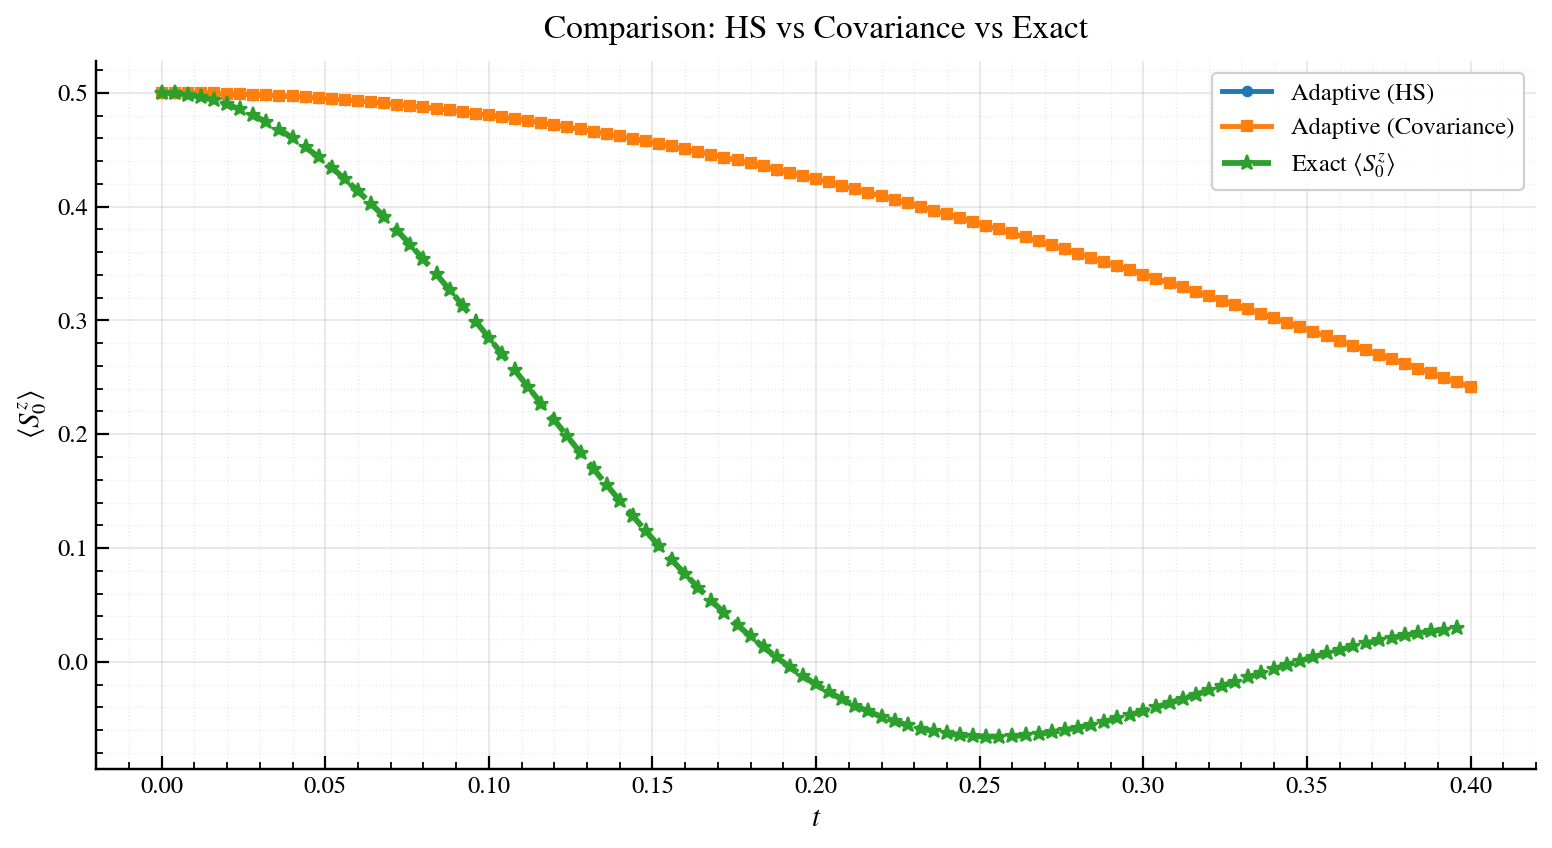

In [18]:
# --- PRETTY + SCIENTIFIC (LaTeX-style), NO DATA CHANGES ---
import matplotlib as mpl
import matplotlib.pyplot as plt

# LaTeX-ish styling (uses mathtext by default; if you *have* LaTeX installed,
# flip usetex=True below)
mpl.rcParams.update({
    "figure.figsize": (9.8, 5.4),
    "figure.dpi": 160,

    # Text / math
    "text.usetex": False,              # set True if you have a LaTeX install
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",

    # Axes
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "axes.titlepad": 10,
    "axes.linewidth": 1.1,

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # Legend
    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.92,
})

fig, ax = plt.subplots()

# Adaptive HS (same data)
ax.plot(
    aligned["t"],
    aligned["y_hs"],
    marker="o",
    markersize=4.2,
    linewidth=2.2,
    label=r"Adaptive (HS)",
)

# Adaptive Covariance (same data)
ax.plot(
    aligned["t"],
    aligned["y_cov"],
    marker="s",
    markersize=4.2,
    linewidth=2.2,
    label=r"Adaptive (Covariance)",
)

# Exact (same data + same slicing)
ax.plot(
    aligned["t"][:-1],
    exp_Sz0,
    marker="*",
    markersize=7.0,
    linewidth=2.6,
    linestyle="--",
    label=r"Exact $\langle S^z_{0}\rangle$",
)

# Labels / title (LaTeX math)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\langle S^z_{0}\rangle$")
ax.set_title(r"Comparison: HS vs Covariance vs Exact")

# Scientific grid: major + minor
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.8, alpha=0.30)
ax.grid(which="minor", linestyle=":", linewidth=0.6, alpha=0.25)

# Clean spines but still “physics plot”
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(loc="best")

plt.tight_layout()
plt.show()


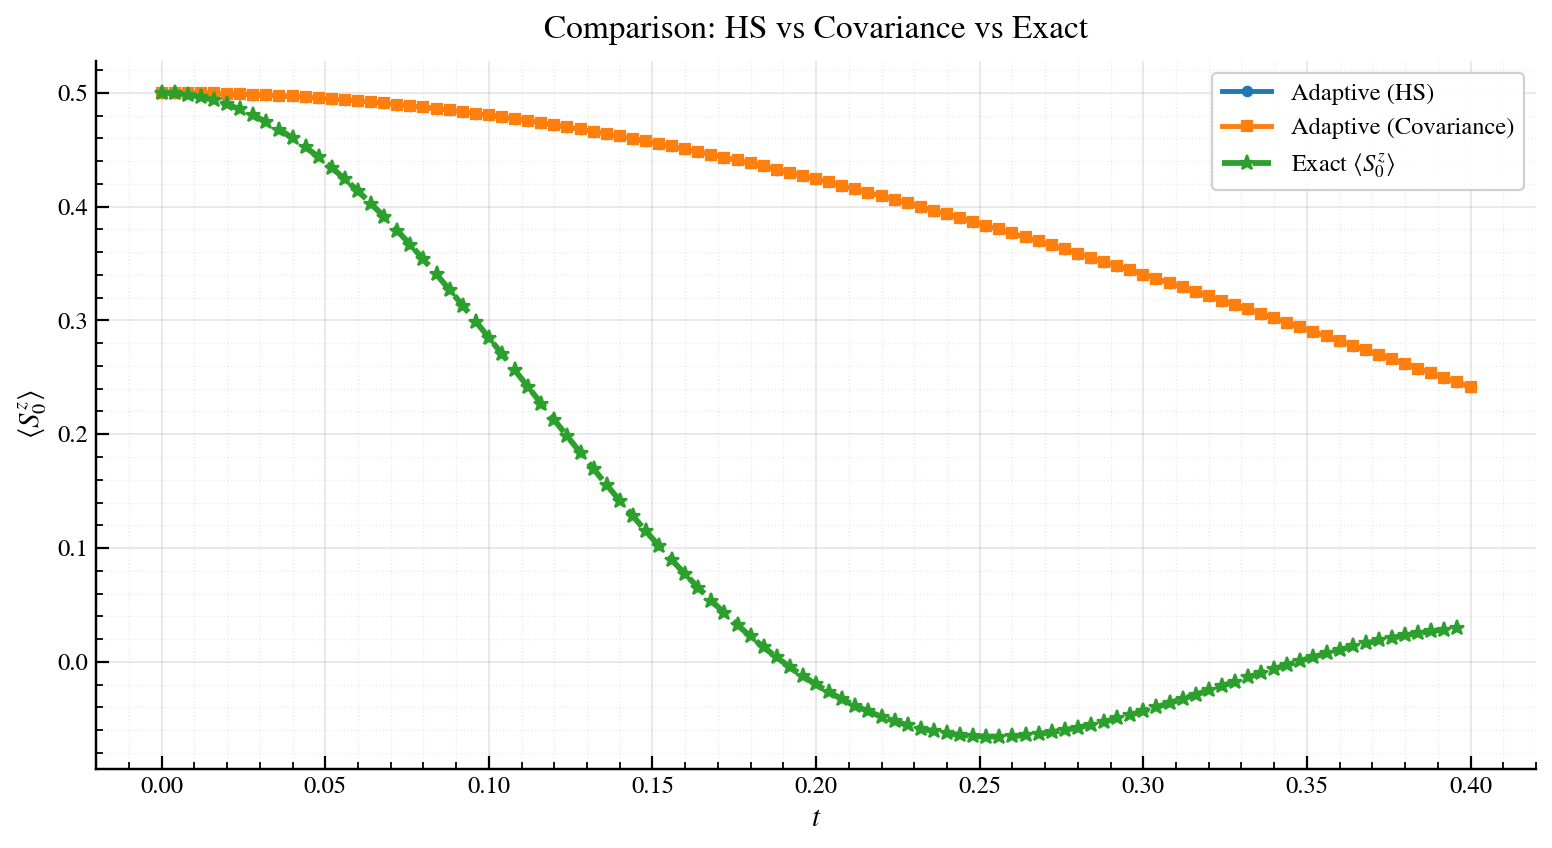

In [19]:
# --- PRETTY + SCIENTIFIC (LaTeX-style), NO DATA CHANGES ---
import matplotlib as mpl
import matplotlib.pyplot as plt

# LaTeX-ish styling (uses mathtext by default; if you *have* LaTeX installed,
# flip usetex=True below)
mpl.rcParams.update({
    "figure.figsize": (9.8, 5.4),
    "figure.dpi": 160,

    # Text / math
    "text.usetex": False,              # set True if you have a LaTeX install
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",

    # Axes
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "axes.titlepad": 10,
    "axes.linewidth": 1.1,

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    # Legend
    "legend.fontsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.92,
})

fig, ax = plt.subplots()

# Adaptive HS (same data)
ax.plot(
    aligned["t"],
    aligned["y_hs"],
    marker="o",
    markersize=4.2,
    linewidth=2.2,
    label=r"Adaptive (HS)",
)

# Adaptive Covariance (same data)
ax.plot(
    aligned["t"],
    aligned["y_cov"],
    marker="s",
    markersize=4.2,
    linewidth=2.2,
    label=r"Adaptive (Covariance)",
)

# Exact (same data + same slicing)
ax.plot(
    aligned["t"][:-1],
    exp_Sz0,
    marker="*",
    markersize=7.0,
    linewidth=2.6,
    linestyle="--",
    label=r"Exact $\langle S^z_{0}\rangle$",
)

# Labels / title (LaTeX math)
ax.set_xlabel(r"$t$")
ax.set_ylabel(r"$\langle S^z_{0}\rangle$")
ax.set_title(r"Comparison: HS vs Covariance vs Exact")

# Scientific grid: major + minor
ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.8, alpha=0.30)
ax.grid(which="minor", linestyle=":", linewidth=0.6, alpha=0.25)

# Clean spines but still “physics plot”
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend
ax.legend(loc="best")

plt.tight_layout()
plt.show()


In [ ]:
# --- Plot: errors vs Exact (if available) ---
if "y_Exact" in aligned.columns:
    fig, ax = plt.subplots(figsize=(9, 4.8))
    err_hs = np.abs(aligned["y_Adaptive_HS"] - aligned["y_Exact"])
    err_cov = np.abs(aligned["y_Adaptive_Covariance"] - aligned["y_Exact"])
    ax.plot(aligned["t"], err_hs, marker="o", markersize=3, linewidth=1.6, label="|HS − Exact|")
    ax.plot(aligned["t"], err_cov, marker="o", markersize=3, linewidth=1.6, label="|Covar − Exact|")
    ax.set_xlabel("t")
    ax.set_ylabel("Absolute error")
    ax.set_yscale("log")
    ax.set_title("Absolute error vs Exact (log scale)")
    ax.legend(loc="best")
    fig.suptitle(supt, y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No Exact series provided/found — skipping error-vs-exact plot.")


### Usage
Edit `path_hs` and `path_covar` at the top, run all. Optionally set `path_exact`.
